# Risk Overlays and Reality Checks

Cost-adjusted promotion logic: realised Sharpe, net Sharpe and leakage guards, on the **synthetic**
futures dataset (seed 13). The equity curve and drawdown come from `openquant.viz.prepare_drawdown_payload`.

In [1]:
import nbfigures
import openquant

ds = openquant.research.make_synthetic_futures_dataset(n_bars=180, seed=13)
out = openquant.research.run_flywheel_iteration(ds)
out["promotion"], out["costs"]

({'passed_realized_sharpe': False,
  'passed_net_sharpe': False,
  'passed_alignment_guard': True,
  'passed_event_order_guard': True,
  'promote_candidate': False},
 {'turnover': 4.4,
  'realized_vol': 0.0020380719416036256,
  'cost_per_turn': 0.00036630457553282904,
  'estimated_total_cost': 0.0016117401323444479,
  'gross_total_return': -0.0006533695739833201,
  'net_total_return': -0.002265109706327768,
  'net_sharpe': -2.228316213074389})

In [2]:
dd_payload = openquant.viz.prepare_drawdown_payload(
    out["backtest"]["timestamps"],
    out["backtest"]["equity_curve"],
)
assert dd_payload["chart"] == "line"
assert "drawdown" in dd_payload
out["summary"]

portfolio_sharpe,portfolio_return,portfolio_risk,realized_sharpe,value_at_risk,expected_shortfall,conditional_drawdown_risk,inputs_aligned,timestamps_increasing,event_indices_sorted,has_forward_look_bias,turnover,realized_vol,estimated_cost,gross_total_return,net_total_return,net_sharpe
f64,f64,f64,f64,f64,f64,f64,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64
1.358183,0.018648,0.01373,-0.449191,-0.000201,-0.000305,0.002903,true,true,true,false,4.4,0.002038,0.001612,-0.000653,-0.002265,-2.228316


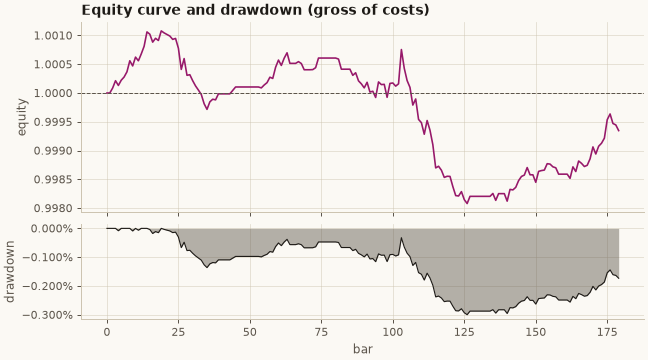

max drawdown: -0.2997%


In [3]:
def draw(fig, c):
    top, bottom = fig.subplots(2, 1, sharex=True, height_ratios=[2, 1])
    x = range(len(dd_payload["equity"]))
    top.plot(x, dd_payload["equity"], color=c["accent"])
    top.axhline(1.0, color=c["muted"], linewidth=0.8, linestyle="--")
    top.set_ylabel("equity")
    top.set_title("Equity curve and drawdown (gross of costs)")
    bottom.fill_between(x, dd_payload["drawdown"], 0.0, color=c["muted"], alpha=0.45, linewidth=0)
    bottom.plot(x, dd_payload["drawdown"], color=c["text"], linewidth=0.9)
    bottom.set_ylabel("drawdown")
    bottom.set_xlabel("bar")
    bottom.yaxis.set_major_formatter(nbfigures.percent)


nbfigures.figure(
    "nb05-equity-drawdown",
    draw,
    size=(7.2, 4.0),
    alt="Equity curve of the synthetic flywheel backtest with its drawdown from the running peak below.",
)
print(f"max drawdown: {min(dd_payload['drawdown']):.4%}")